In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
print(weekly.dtypes)
print()
print(weekly.head())

Store                  int64
WeekEnding    datetime64[us]
Sales                  int64
PromoShare           float64
OpenDays               int64
dtype: object

   Store WeekEnding  Sales  PromoShare  OpenDays
0    198 2013-01-06   7553        0.00         4
1    198 2013-01-13  25250        0.83         6
2    198 2013-01-20  10544        0.00         6
3    198 2013-01-27  22567        0.83         6
4    198 2013-02-03  11020        0.00         6


In [26]:
# Cell — Rolling-origin backtest, written out explicitly
#
# Random train/test splitting leaks future information into training and makes
# any resulting score meaningless. A forecast must be evaluated the way it is
# used: standing at week t, seeing only weeks 1..t, predicting t+1..t+H.
#
# Each iteration below reproduces one replenishment decision. The first and last
# weeks are dropped: they are truncated by the dataset boundary (the panel starts
# on a Tuesday and ends on a Thursday), so their totals reflect missing days
# rather than trading behaviour.

import numpy as np
import pandas as pd

H = config.HORIZON
MIN_TRAIN = config.MIN_TRAIN_WEEKS
SEASON = config.SEASON_LENGTH

# Drop boundary-truncated weeks
bounds = weekly.groupby("Store")["WeekEnding"].agg(["min", "max"])
mask = weekly.apply(
    lambda r: r["WeekEnding"] not in (bounds.loc[r["Store"], "min"],
                                      bounds.loc[r["Store"], "max"]),
    axis=1,
)
panel = weekly[mask].copy()
print(f"Weeks retained: {len(panel)} of {len(weekly)}")


def seasonal_naive_forecast(history, h, m=SEASON):
    """Same week last year. A deliberately strong baseline for retail."""
    if len(history) < m:
        return np.repeat(history.iloc[-1], h)
    return np.array([history.iloc[-m + (i % m)] for i in range(h)])


results = []

for store, g in panel.groupby("Store"):
    s = g.sort_values("WeekEnding").set_index("WeekEnding")["Sales"].astype(float)

    for t in range(MIN_TRAIN, len(s) - H + 1):
        history = s.iloc[:t]          # everything known at the decision point
        actual = s.iloc[t:t + H]      # what actually happened, unseen at time t

        pred = seasonal_naive_forecast(history, H)

        for i in range(H):
            results.append({
                "store": store,
                "origin": s.index[t - 1],
                "target_date": actual.index[i],
                "h": i + 1,
                "y_true": actual.iloc[i],
                "y_pred": pred[i],
            })

bt = pd.DataFrame(results)
bt["error"] = bt["y_pred"] - bt["y_true"]     # positive = over-forecast

print(f"Origins per store: {bt.groupby('store')['origin'].nunique().to_dict()}")
print(f"Total scored predictions: {len(bt):,}\n")

print("Seasonal naive accuracy by store and horizon:")
print(
    bt.groupby(["store", "h"])
      .apply(lambda x: pd.Series({
          "RMSE": np.sqrt((x["error"] ** 2).mean()),
          "MAPE_%": (x["error"].abs() / x["y_true"]).mean() * 100,
          "bias_%": x["error"].mean() / x["y_true"].mean() * 100,
      }), include_groups=False)
      .round(2)
)

Weeks retained: 266 of 270
Origins per store: {198: 53, 733: 53}
Total scored predictions: 318

Seasonal naive accuracy by store and horizon:
            RMSE  MAPE_%  bias_%
store h                         
198   1 5,703.76   23.91   -0.44
      2 5,707.35   23.94   -0.34
      3 5,698.87   23.90   -0.75
733   1 9,463.91    7.14   -3.29
      2 9,476.04    7.16   -3.10
      3 9,472.31    7.15   -3.01


In [27]:
# Cell — Cumulative forecast error over the protection period
#
# Safety stock does not absorb weekly error; it absorbs the error of *cumulative*
# demand across the protection period P = R + L. The two aggregate differently:
# independent noise grows with sqrt(P), while bias grows linearly with P. A model
# that is noisy but unbiased can therefore need less safety stock than one that
# looks more accurate week by week but drifts in one direction.

cum = (
    bt.groupby(["store", "origin"])
      .agg(forecast_P=("y_pred", "sum"), actual_P=("y_true", "sum"))
      .reset_index()
)
cum["error_P"] = cum["forecast_P"] - cum["actual_P"]

summary = cum.groupby("store").agg(
    mean_demand_P=("actual_P", "mean"),
    bias_P=("error_P", "mean"),
    noise_std_P=("error_P", "std"),
)
summary["bias_%"] = summary["bias_P"] / summary["mean_demand_P"] * 100
summary["noise_%"] = summary["noise_std_P"] / summary["mean_demand_P"] * 100

# If weekly errors were independent, cumulative std would be weekly_std * sqrt(P).
weekly_std = bt.groupby("store")["error"].std()
summary["expected_if_independent"] = weekly_std * np.sqrt(H)
summary["autocorrelation_factor"] = (
    summary["noise_std_P"] / summary["expected_if_independent"]
)

print("Cumulative error over the 3-week protection period:")
print(summary.round(2))

Cumulative error over the 3-week protection period:
       mean_demand_P     bias_P  noise_std_P  bias_%  noise_%  \
store                                                           
198        50,685.42    -258.53     5,624.61   -0.51    11.10   
733       322,616.09 -10,109.98    17,374.41   -3.13     5.39   

       expected_if_independent  autocorrelation_factor  
store                                                   
198                   9,908.53                    0.57  
733                  15,378.64                    1.13  


In [28]:
# Cell — Price the gap between the textbook formula and reality
#
# The standard safety stock formula SS = z * sigma_weekly * sqrt(L) assumes
# weekly forecast errors are independent. The autocorrelation factors computed
# above show they are not: store 198's errors cancel across the protection
# period (0.57) while store 733's persist (1.13). Using the formula therefore
# overstocks one store and understocks the other. Bias is treated separately:
# a persistent one-directional error is not uncertainty and should be removed
# by correction, not absorbed by inventory.

from statistics import NormalDist

z = NormalDist().inv_cdf(config.SERVICE_LEVEL)
rate = config.CARRYING_RATE_ANNUAL

out = summary.copy()
out["ss_textbook"] = z * out["expected_if_independent"]
out["ss_empirical"] = z * out["noise_std_P"]
out["ss_error_EUR"] = out["ss_textbook"] - out["ss_empirical"]
out["annual_cost_of_error"] = out["ss_error_EUR"].abs() * rate

# Uncorrected bias must be carried as additional stock on top of safety stock.
out["bias_stock_EUR"] = out["bias_P"].clip(upper=0).abs()
out["annual_cost_of_bias"] = out["bias_stock_EUR"] * rate

print(f"Service level {config.SERVICE_LEVEL:.0%} (z = {z:.3f}), "
      f"carrying rate {rate:.0%}/year\n")
print(out[[
    "ss_textbook", "ss_empirical", "ss_error_EUR", "annual_cost_of_error",
    "bias_stock_EUR", "annual_cost_of_bias",
]].round(0).to_string())

print("\nSafety stock as a share of protection-period demand:")
print((out["ss_empirical"] / out["mean_demand_P"] * 100).round(1).to_string())

Service level 95% (z = 1.645), carrying rate 20%/year

       ss_textbook  ss_empirical  ss_error_EUR  annual_cost_of_error  bias_stock_EUR  annual_cost_of_bias
store                                                                                                    
198      16,298.00      9,252.00      7,046.00              1,409.00          259.00                52.00
733      25,296.00     28,578.00     -3,283.00                657.00       10,110.00             2,022.00

Safety stock as a share of protection-period demand:
store
198   18.30
733    8.90


In [29]:
# Cell — Build the promotion plan as a separate artefact
#
# Promotion schedules are decisions made by the retailer, not outcomes generated
# by customers. Rossmann's marketing department fixes them weeks ahead, so they
# are available at the moment a replenishment decision is taken. In forecasting
# terms they are a *known future covariate*, and excluding them would discard
# information the planner already holds.
#
# The plan is materialised here as a standalone table rather than read from the
# sales panel during backtesting. Numerically the values are identical; the
# separation is what makes it auditable that the model reads a published plan
# and not the realised future.

promo_plan = (
    panel[["Store", "WeekEnding", "PromoShare"]]
    .copy()
    .assign(
        # Explicit statement of the assumption being made.
        known_at=lambda x: x["WeekEnding"] - pd.Timedelta(weeks=config.HORIZON),
        is_promo=lambda x: x["PromoShare"] > 0,
    )
    .set_index(["Store", "WeekEnding"])
)

print("Promotion plan:")
print(promo_plan.head())
print(f"\nPromo weeks per store:")
print(promo_plan.groupby("Store")["is_promo"].agg(["sum", "count"]))

Promotion plan:
                  PromoShare   known_at  is_promo
Store WeekEnding                                 
198   2013-01-13        0.83 2012-12-23      True
      2013-01-20        0.00 2012-12-30     False
      2013-01-27        0.83 2013-01-06      True
      2013-02-03        0.00 2013-01-13     False
      2013-02-10        0.83 2013-01-20      True

Promo weeks per store:
       sum  count
Store            
198     71    133
733     71    133


In [30]:
# Cell — Promo-aware conditional mean vs seasonal naive
#
# The model is deliberately minimal: the mean of recent promo weeks and the mean
# of recent non-promo weeks, selected by the published plan for the target week.
# No machine learning, no tuning. Any improvement is therefore attributable to
# the promotion information itself rather than to model complexity — which is
# the effect this project sets out to measure.

WINDOW = 26   # weeks of history used to estimate each conditional mean

def promo_aware_forecast(history, hist_promo, future_promo):
    """Conditional mean, selected by the published promotion plan."""
    recent = history.iloc[-WINDOW:]
    recent_promo = hist_promo.iloc[-WINDOW:]

    mean_promo = recent[recent_promo].mean()
    mean_base = recent[~recent_promo].mean()

    # Fall back to the pooled mean if a regime is absent from the window.
    if np.isnan(mean_promo):
        mean_promo = recent.mean()
    if np.isnan(mean_base):
        mean_base = recent.mean()

    return np.array([mean_promo if p else mean_base for p in future_promo])


rows = []

for store, g in panel.groupby("Store"):
    g = g.sort_values("WeekEnding").set_index("WeekEnding")
    s = g["Sales"].astype(float)
    plan = promo_plan.loc[store, "is_promo"]

    for t in range(MIN_TRAIN, len(s) - H + 1):
        history = s.iloc[:t]
        hist_promo = plan.iloc[:t]
        actual = s.iloc[t:t + H]
        future_promo = plan.iloc[t:t + H]        # read from the plan, not from sales

        preds = {
            "seasonal_naive": seasonal_naive_forecast(history, H),
            "promo_aware": promo_aware_forecast(history, hist_promo, future_promo),
        }

        for name, yhat in preds.items():
            for i in range(H):
                rows.append({
                    "store": store,
                    "model": name,
                    "origin": s.index[t - 1],
                    "h": i + 1,
                    "y_true": actual.iloc[i],
                    "y_pred": yhat[i],
                    "promo": bool(future_promo.iloc[i]),
                })

bt2 = pd.DataFrame(rows)
bt2["error"] = bt2["y_pred"] - bt2["y_true"]

print("Weekly accuracy:")
print(
    bt2.groupby(["store", "model"])
       .apply(lambda x: pd.Series({
           "RMSE": np.sqrt((x["error"] ** 2).mean()),
           "MAPE_%": (x["error"].abs() / x["y_true"]).mean() * 100,
           "bias_%": x["error"].mean() / x["y_true"].mean() * 100,
       }), include_groups=False)
       .round(2)
)

Weekly accuracy:
                         RMSE  MAPE_%  bias_%
store model                                  
198   promo_aware    2,229.71    8.06   -0.06
      seasonal_naive 5,703.33   23.92   -0.51
733   promo_aware    8,239.05    6.21   -0.42
      seasonal_naive 9,470.76    7.15   -3.13


In [31]:
# Cell — Convert the accuracy gain into inventory terms
#
# Weekly accuracy improved sharply, but safety stock responds to the standard
# deviation of *cumulative* error over the protection period, not to weekly
# error. The seasonal naive baseline benefited from error cancellation across
# the promotion cycle (autocorrelation factor 0.57 at store 198); removing that
# error may also remove the cancellation. This measures what the accuracy gain
# is actually worth.

from statistics import NormalDist

z = NormalDist().inv_cdf(config.SERVICE_LEVEL)
rate = config.CARRYING_RATE_ANNUAL

cum2 = (
    bt2.groupby(["store", "model", "origin"])
       .agg(forecast_P=("y_pred", "sum"), actual_P=("y_true", "sum"))
       .reset_index()
)
cum2["error_P"] = cum2["forecast_P"] - cum2["actual_P"]

res = cum2.groupby(["store", "model"]).agg(
    mean_demand_P=("actual_P", "mean"),
    bias_P=("error_P", "mean"),
    std_P=("error_P", "std"),
)

weekly_std = bt2.groupby(["store", "model"])["error"].std()
res["autocorr_factor"] = res["std_P"] / (weekly_std * np.sqrt(H))

res["safety_stock"] = z * res["std_P"]
res["bias_stock"] = res["bias_P"].clip(upper=0).abs()
res["total_stock"] = res["safety_stock"] + res["bias_stock"]
res["annual_carrying"] = res["total_stock"] * rate
res["stock_pct_of_demand"] = res["total_stock"] / res["mean_demand_P"] * 100

print(f"Service level {config.SERVICE_LEVEL:.0%}, carrying rate {rate:.0%}/year\n")
print(res[["autocorr_factor", "safety_stock", "bias_stock",
           "total_stock", "annual_carrying", "stock_pct_of_demand"]].round(1).to_string())

print("\nValue of the promo-aware model, per store:")
for store in res.index.get_level_values("store").unique():
    base = res.loc[(store, "seasonal_naive")]
    new = res.loc[(store, "promo_aware")]
    mape_gain = 1 - (
        bt2[(bt2.store == store) & (bt2.model == "promo_aware")]["error"].abs().mean()
        / bt2[(bt2.store == store) & (bt2.model == "seasonal_naive")]["error"].abs().mean()
    )
    stock_gain = 1 - new["total_stock"] / base["total_stock"]
    print(f"  Store {store}: MAE -{mape_gain:.0%} | stock -{stock_gain:.0%} | "
          f"saving EUR {base['annual_carrying'] - new['annual_carrying']:,.0f}/year")

Service level 95%, carrying rate 20%/year

                      autocorr_factor  safety_stock  bias_stock  total_stock  annual_carrying  stock_pct_of_demand
store model                                                                                                       
198   promo_aware                1.40      8,683.60       29.10     8,712.60         1,742.50                17.20
      seasonal_naive             0.60      9,251.70      258.50     9,510.20         1,902.00                18.80
733   promo_aware                1.10     26,452.70    1,360.50    27,813.10         5,562.60                 8.60
      seasonal_naive             1.10     28,578.40   10,110.00    38,688.30         7,737.70                12.00

Value of the promo-aware model, per store:
  Store 198: MAE -62% | stock -8% | saving EUR 160/year
  Store 733: MAE -14% | stock -28% | saving EUR 2,175/year


In [32]:
# Cell — Simulate the replenishment policy instead of trusting the formula
#
# Safety stock has so far been computed as z * sigma, which assumes normally
# distributed, independent errors and treats inventory as a static quantity.
# The measured autocorrelation factors (0.60 and 1.40) already contradict the
# independence assumption. This simulates the periodic-review (R, S) policy
# against the demand that actually occurred, and measures the service level
# achieved rather than the one promised.
#
# Event sequence within each week, in order:
#   1. receive any order arriving this week
#   2. review stock and place an order to bring inventory position up to S
#   3. demand occurs and depletes on-hand stock
# Ordering before demand matters: reversing steps 2 and 3 lets the planner see
# the week's sales before deciding, which no real planner can do.

L = config.LEAD_TIME
WARMUP = 10   # weeks discarded so the starting condition does not bias results


def simulate_policy(bt, store, model, safety_stock, lead_time=L, warmup=WARMUP):
    """Periodic-review (R, S) policy. Returns achieved service and holding."""
    d = bt[(bt.store == store) & (bt.model == model)].sort_values(["origin", "h"])

    # Order-up-to level: forecast demand over the protection period + buffer
    S = d.groupby("origin")["y_pred"].sum() + safety_stock
    demand = d[d.h == 1].set_index("origin")["y_true"]
    origins = list(S.index)

    on_hand = float(S.iloc[0])
    pipeline = {}
    unmet_total = demand_total = 0.0
    stockout_weeks = scored_weeks = 0
    on_hand_track = []

    for i, o in enumerate(origins):
        on_hand += pipeline.pop(i, 0.0)                       # 1. receive

        position = on_hand + sum(pipeline.values())           # 2. review, order
        qty = max(0.0, S[o] - position)
        pipeline[i + lead_time] = pipeline.get(i + lead_time, 0.0) + qty

        dmd = demand[o]                                       # 3. demand
        sold = min(on_hand, dmd)
        unmet = dmd - sold
        on_hand -= sold

        if i >= warmup:
            scored_weeks += 1
            demand_total += dmd
            unmet_total += unmet
            if unmet > 1e-6:
                stockout_weeks += 1
            on_hand_track.append(on_hand)

    return pd.Series({
        "safety_stock": safety_stock,
        "CSL_achieved": 1 - stockout_weeks / scored_weeks,
        "fill_rate": 1 - unmet_total / demand_total,
        "avg_on_hand": np.mean(on_hand_track),
        "weeks": scored_weeks,
    })


sim = []
for (store, model), g in cum2.groupby(["store", "model"]):
    ss = z * g["error_P"].std()
    r = simulate_policy(bt2, store, model, ss)
    r["store"], r["model"] = store, model
    sim.append(r)

sim = pd.DataFrame(sim).set_index(["store", "model"])
sim["annual_carrying"] = sim["avg_on_hand"] * config.CARRYING_RATE_ANNUAL

print(f"Target cycle service level: {config.SERVICE_LEVEL:.0%}\n")
print(sim[["safety_stock", "CSL_achieved", "fill_rate",
           "avg_on_hand", "annual_carrying"]].round(3).to_string())

Target cycle service level: 95%

                       safety_stock  CSL_achieved  fill_rate  avg_on_hand  annual_carrying
store  model                                                                              
198.00 promo_aware         8,683.56          0.95       0.99     9,726.70         1,945.34
       seasonal_naive      9,251.65          0.98       1.00     9,126.95         1,825.39
733.00 promo_aware        26,452.67          0.95       1.00    25,986.81         5,197.36
       seasonal_naive     28,578.36          0.91       1.00    22,697.46         4,539.49


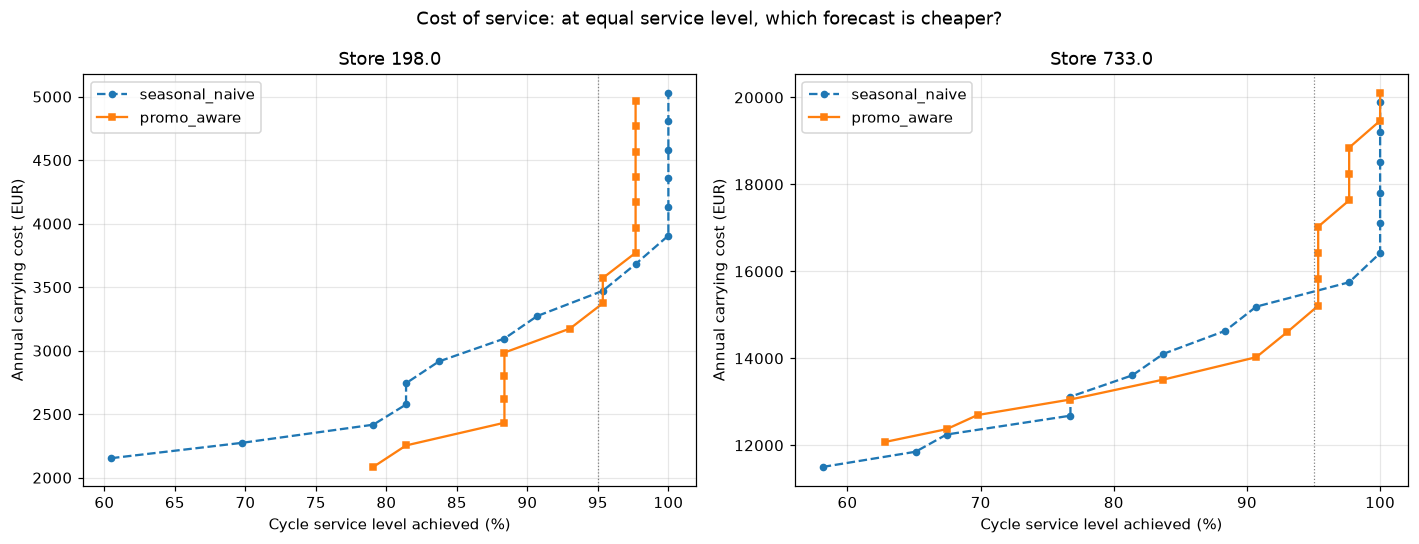

Cheapest configuration reaching at least 95% CSL:

  Store 198.0 seasonal_naive  k=1.6 cost EUR     3,471/yr  CSL 95.3%  fill 99.82%
  Store 198.0 promo_aware     k=1.4 cost EUR     3,373/yr  CSL 95.3%  fill 98.46%

  Store 733.0 seasonal_naive  k=1.8 cost EUR    15,749/yr  CSL 97.7%  fill 99.98%
  Store 733.0 promo_aware     k=1.4 cost EUR    15,209/yr  CSL 95.3%  fill 99.54%



In [33]:
# Cell — Service level vs cost efficient frontier
#
# Comparing two models at different achieved service levels is meaningless. The
# frontier sweeps safety stock across a grid, simulates each setting, and records
# the service level actually delivered alongside the cost of delivering it. The
# comparison is then horizontal: at a fixed service level, which model is cheaper?
#
# Inventory is measured as the average of start-of-week and end-of-week on-hand,
# which approximates mid-week holding. Measuring end-of-week stock alone (as in
# the previous cell) understates carrying cost by roughly half a cycle.

import matplotlib.pyplot as plt

def simulate_policy(bt, store, model, safety_stock, lead_time=L, warmup=WARMUP):
    d = bt[(bt.store == store) & (bt.model == model)].sort_values(["origin", "h"])
    S = d.groupby("origin")["y_pred"].sum() + safety_stock
    demand = d[d.h == 1].set_index("origin")["y_true"]
    origins = list(S.index)

    on_hand = float(S.iloc[0])
    pipeline = {}
    unmet_total = demand_total = 0.0
    stockout_weeks = scored = 0
    inventory = []

    for i, o in enumerate(origins):
        on_hand += pipeline.pop(i, 0.0)
        start = on_hand

        position = on_hand + sum(pipeline.values())
        qty = max(0.0, S[o] - position)
        pipeline[i + lead_time] = pipeline.get(i + lead_time, 0.0) + qty

        dmd = demand[o]
        sold = min(on_hand, dmd)
        unmet = dmd - sold
        on_hand -= sold

        if i >= warmup:
            scored += 1
            demand_total += dmd
            unmet_total += unmet
            if unmet > 1e-6:
                stockout_weeks += 1
            inventory.append((start + on_hand) / 2)

    return pd.Series({
        "CSL": 1 - stockout_weeks / scored,
        "fill_rate": 1 - unmet_total / demand_total,
        "avg_inventory": np.mean(inventory),
    })


GRID = np.arange(0.0, 3.01, 0.2)   # safety stock in multiples of sigma_P

frontier = []
for (store, model), g in cum2.groupby(["store", "model"]):
    sigma = g["error_P"].std()
    for k in GRID:
        r = simulate_policy(bt2, store, model, k * sigma)
        r["store"], r["model"], r["k"] = store, model, k
        r["safety_stock"] = k * sigma
        frontier.append(r)

frontier = pd.DataFrame(frontier)
frontier["annual_cost"] = frontier["avg_inventory"] * config.CARRYING_RATE_ANNUAL

# --- plot -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, store in zip(axes, sorted(frontier["store"].unique())):
    for model, style in [("seasonal_naive", "o--"), ("promo_aware", "s-")]:
        sub = frontier[(frontier.store == store) & (frontier.model == model)]
        ax.plot(sub["CSL"] * 100, sub["annual_cost"], style, label=model, markersize=4)
    ax.axvline(config.SERVICE_LEVEL * 100, color="grey", lw=0.8, ls=":")
    ax.set_title(f"Store {store}")
    ax.set_xlabel("Cycle service level achieved (%)")
    ax.set_ylabel("Annual carrying cost (EUR)")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Cost of service: at equal service level, which forecast is cheaper?")
fig.tight_layout()
fig.savefig("../outputs/service_cost_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

# --- cost at a matched service level --------------------------------------
TARGET = config.SERVICE_LEVEL
print(f"Cheapest configuration reaching at least {TARGET:.0%} CSL:\n")
for store in sorted(frontier["store"].unique()):
    for model in ["seasonal_naive", "promo_aware"]:
        sub = frontier[(frontier.store == store) & (frontier.model == model)]
        ok = sub[sub["CSL"] >= TARGET]
        if len(ok):
            best = ok.loc[ok["annual_cost"].idxmin()]
            print(f"  Store {store} {model:15s} k={best['k']:.1f} "
                  f"cost EUR {best['annual_cost']:>9,.0f}/yr  "
                  f"CSL {best['CSL']:.1%}  fill {best['fill_rate']:.2%}")
        else:
            print(f"  Store {store} {model:15s} never reaches {TARGET:.0%}")
    print()
    

In [34]:
# Cell — Fair comparison at exactly matched service, on both service definitions
#
# The coarse grid lets one configuration overshoot the target (store 733's
# baseline reaches 97.7% where the promo-aware model reaches 95.3%), so the
# apparent saving is partly a comparison of unequal service. Interpolating cost
# as a function of achieved service removes that artefact.
#
# The comparison is repeated on fill rate, because the two definitions do not
# rank the models identically: at store 198 the promo-aware model matches CSL
# but delivers lower fill rate, its stockouts being fewer in number but deeper.

GRID_FINE = np.arange(0.0, 3.01, 0.05)

fine = []
for (store, model), g in cum2.groupby(["store", "model"]):
    sigma = g["error_P"].std()
    for k in GRID_FINE:
        r = simulate_policy(bt2, store, model, k * sigma)
        r["store"], r["model"], r["k"] = store, model, k
        fine.append(r)

fine = pd.DataFrame(fine)
fine["annual_cost"] = fine["avg_inventory"] * config.CARRYING_RATE_ANNUAL


def cost_at(sub, metric, target):
    """Cheapest cost that reliably achieves the target, by monotone interpolation."""
    s = sub.sort_values("k")
    # Cost required is the running minimum cost among settings that meet target
    ok = s[s[metric] >= target]
    return ok["annual_cost"].min() if len(ok) else np.nan


print("Annual carrying cost at matched service level\n")
for metric, targets in [("CSL", [0.90, 0.95, 0.98]),
                        ("fill_rate", [0.98, 0.99, 0.995])]:
    print(f"--- matched on {metric} ---")
    for store in sorted(fine["store"].unique()):
        for target in targets:
            row = {}
            for model in ["seasonal_naive", "promo_aware"]:
                sub = fine[(fine.store == store) & (fine.model == model)]
                row[model] = cost_at(sub, metric, target)
            gap = row["seasonal_naive"] - row["promo_aware"]
            print(f"  Store {store} @ {target:.1%}: "
                  f"baseline {row['seasonal_naive']:>9,.0f} | "
                  f"promo-aware {row['promo_aware']:>9,.0f} | "
                  f"saving {gap:>8,.0f}")
    print()

Annual carrying cost at matched service level

--- matched on CSL ---
  Store 198.0 @ 90.0%: baseline     3,273 | promo-aware     3,032 | saving      241
  Store 198.0 @ 95.0%: baseline     3,471 | promo-aware     3,323 | saving      148
  Store 198.0 @ 98.0%: baseline     3,737 | promo-aware       nan | saving      nan
  Store 733.0 @ 90.0%: baseline    14,906 | promo-aware    14,026 | saving      880
  Store 733.0 @ 95.0%: baseline    15,749 | promo-aware    15,058 | saving      691
  Store 733.0 @ 98.0%: baseline    16,077 | promo-aware    19,304 | saving   -3,226

--- matched on fill_rate ---
  Store 198.0 @ 98.0%: baseline     2,786 | promo-aware     2,985 | saving     -199
  Store 198.0 @ 99.0%: baseline     3,141 | promo-aware     4,119 | saving     -978
  Store 198.0 @ 99.5%: baseline     3,273 | promo-aware     4,815 | saving   -1,542
  Store 733.0 @ 98.0%: baseline    12,681 | promo-aware    12,609 | saving       72
  Store 733.0 @ 99.0%: baseline    13,856 | promo-aware    1

In [35]:
# Cell — Stress test the lead-time assumption
#
# Lead time is not observed in the dataset; L = 2 was assumed. Every result so
# far depends on it, because the protection period P = R + L determines both the
# forecast horizon and the window over which forecast errors accumulate.
#
# There is a specific reason to suspect sensitivity. The promotion calendar
# alternates weekly, so P = 3 spans roughly 1.5 promotion cycles and the
# baseline's alternating errors partly cancel. P = 2 would span exactly one
# cycle (cancellation should be near-complete), while P = 5 spans 2.5. If the
# findings are driven by the parity between protection period and promotion
# cycle rather than by the forecasting models themselves, that must be stated.

def run_backtest_for_lead_time(panel, promo_plan, lead_time):
    """Re-run the full backtest with a different protection period."""
    P = config.REVIEW_PERIOD + lead_time
    rows = []

    for store, g in panel.groupby("Store"):
        g = g.sort_values("WeekEnding").set_index("WeekEnding")
        s = g["Sales"].astype(float)
        plan = promo_plan.loc[store, "is_promo"]

        for t in range(MIN_TRAIN, len(s) - P + 1):
            history, hist_promo = s.iloc[:t], plan.iloc[:t]
            actual, future_promo = s.iloc[t:t + P], plan.iloc[t:t + P]

            preds = {
                "seasonal_naive": seasonal_naive_forecast(history, P),
                "promo_aware": promo_aware_forecast(history, hist_promo, future_promo),
            }
            for name, yhat in preds.items():
                for i in range(P):
                    rows.append({
                        "store": store, "model": name, "origin": s.index[t - 1],
                        "h": i + 1, "y_true": actual.iloc[i], "y_pred": yhat[i],
                    })

    bt = pd.DataFrame(rows)
    bt["error"] = bt["y_pred"] - bt["y_true"]
    return bt, P


stress = []
for lead_time in [1, 2, 4]:
    bt_L, P = run_backtest_for_lead_time(panel, promo_plan, lead_time)

    cum_L = (
        bt_L.groupby(["store", "model", "origin"])
            .agg(forecast_P=("y_pred", "sum"), actual_P=("y_true", "sum"))
            .reset_index()
    )
    cum_L["error_P"] = cum_L["forecast_P"] - cum_L["actual_P"]
    weekly_std = bt_L.groupby(["store", "model"])["error"].std()

    for (store, model), g in cum_L.groupby(["store", "model"]):
        sigma = g["error_P"].std()

        # Cheapest configuration reaching the CSL target
        best = np.nan
        for k in np.arange(0.0, 3.51, 0.1):
            r = simulate_policy(bt_L, store, model, k * sigma, lead_time=lead_time)
            if r["CSL"] >= config.SERVICE_LEVEL:
                cost = r["avg_inventory"] * config.CARRYING_RATE_ANNUAL
                best = cost if np.isnan(best) else min(best, cost)

        stress.append({
            "lead_time": lead_time,
            "P": P,
            "promo_cycles": P / 2,          # promotion alternates weekly
            "store": store,
            "model": model,
            "autocorr": sigma / (weekly_std[(store, model)] * np.sqrt(P)),
            "cost_at_target": best,
        })

stress = pd.DataFrame(stress)

print("Error autocorrelation by protection period:")
print(stress.pivot_table(index=["store", "model"],
                         columns="P", values="autocorr").round(2).to_string())

print("\nAnnual carrying cost at 95% CSL:")
print(stress.pivot_table(index=["store", "model"],
                         columns="P", values="cost_at_target").round(0).to_string())

print("\nSaving from the promo-aware model, by protection period:")
for (store, P), g in stress.groupby(["store", "P"]):
    c = g.set_index("model")["cost_at_target"]
    print(f"  Store {store}, P={P} ({P/2:.1f} promo cycles): "
          f"saving EUR {c['seasonal_naive'] - c['promo_aware']:>8,.0f}/year")

Error autocorrelation by protection period:
P                       2    3    5
store model                        
198   promo_aware    1.22 1.36 1.56
      seasonal_naive 0.41 0.57 0.44
733   promo_aware    1.05 1.13 1.14
      seasonal_naive 1.01 1.13 1.22

Annual carrying cost at 95% CSL:
P                            2         3         5
store model                                       
198   promo_aware     3,001.00  3,373.00  4,077.00
      seasonal_naive  3,344.00  3,471.00  3,503.00
733   promo_aware    15,529.00 15,209.00 19,458.00
      seasonal_naive 13,853.00 15,749.00 16,928.00

Saving from the promo-aware model, by protection period:
  Store 198, P=2 (1.0 promo cycles): saving EUR      343/year
  Store 198, P=3 (1.5 promo cycles): saving EUR       98/year
  Store 198, P=5 (2.5 promo cycles): saving EUR     -574/year
  Store 733, P=2 (1.0 promo cycles): saving EUR   -1,675/year
  Store 733, P=3 (1.5 promo cycles): saving EUR      539/year
  Store 733, P=5 (2.5 promo cycl